In [1]:
import pandas as pd
from ggner_3d.boundaries import make_tads, assign_domain_score
from ggner_3d.cm import get_expected_cis_df, prepare_view_df, CLR_CONNS
from ggner_3d import plotting
plotting.update_rcparams()

from coolpuppy import coolpup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

window_bp = 1_000_000
bin_bp = 10_000
tolerance_bp = 10_000
clr_ = CLR_CONNS(resolution=bin_bp)
NPROC = 6

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
wtnouv_insulation = pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv')

In [3]:
wtnouv_boundaries = wtnouv_insulation.loc[wtnouv_insulation[f'is_boundary_{window_bp}'] == True][['chrom', 'start', 'end']]
wtnouv_tads = make_tads(wtnouv_boundaries, maxlen=3e6)

In [4]:
tad_str = assign_domain_score(
    tads_df=wtnouv_tads,
    clr=clr_['WTnoUV'],
    expected=get_expected_cis_df('WTnoUV', resolution_kb=bin_bp // 1000, label='chrom'),
    view_df=prepare_view_df(arm=False),
    resolution=bin_bp,
    nproc=NPROC,
    clr_weight_name='sweight',
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 129
INFO:coolpuppy:('chr5', 'chr5'): 125
INFO:coolpuppy:('chr4', 'chr4'): 125
INFO:coolpuppy:('chr3', 'chr3'): 161
INFO:coolpuppy:('chr1', 'chr1'): 189
INFO:coolpuppy:('chr2', 'chr2'): 167
INFO:coolpuppy:('chr9', 'chr9'): 90
INFO:coolpuppy:('chr7', 'chr7'): 105
INFO:coolpuppy:('chr8', 'chr8'): 106
INFO:coolpuppy:('chr10', 'chr10'): 99
INFO:coolpuppy:('chr11', 'chr11'): 110
INFO:coolpuppy:('chr13', 'chr13'): 65
INFO:coolpuppy:('chr12', 'chr12'): 112
INFO:coolpuppy:('chr14', 'chr14'): 74
INFO:coolpuppy:('chr16', 'chr16'): 55
INFO:coolpuppy:('chr15', 'chr15'): 67
INFO:coolpuppy:('chr17', 'chr17'): 62
INFO:coolpuppy:('chr19', 'chr19'): 42
INFO:coolpuppy:('chr21', 'chr21'): 15
INFO:coolpuppy:('chr22', 'chr22'): 26
INFO:coolpuppy:('chr18', 'chr18'): 53
INFO:coolpuppy:('chr20', 'chr20'): 50
INFO:coolpuppy:('chrX', 'chrX'): 98
INFO:coolpuppy:Total number of piled up windows: 189


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


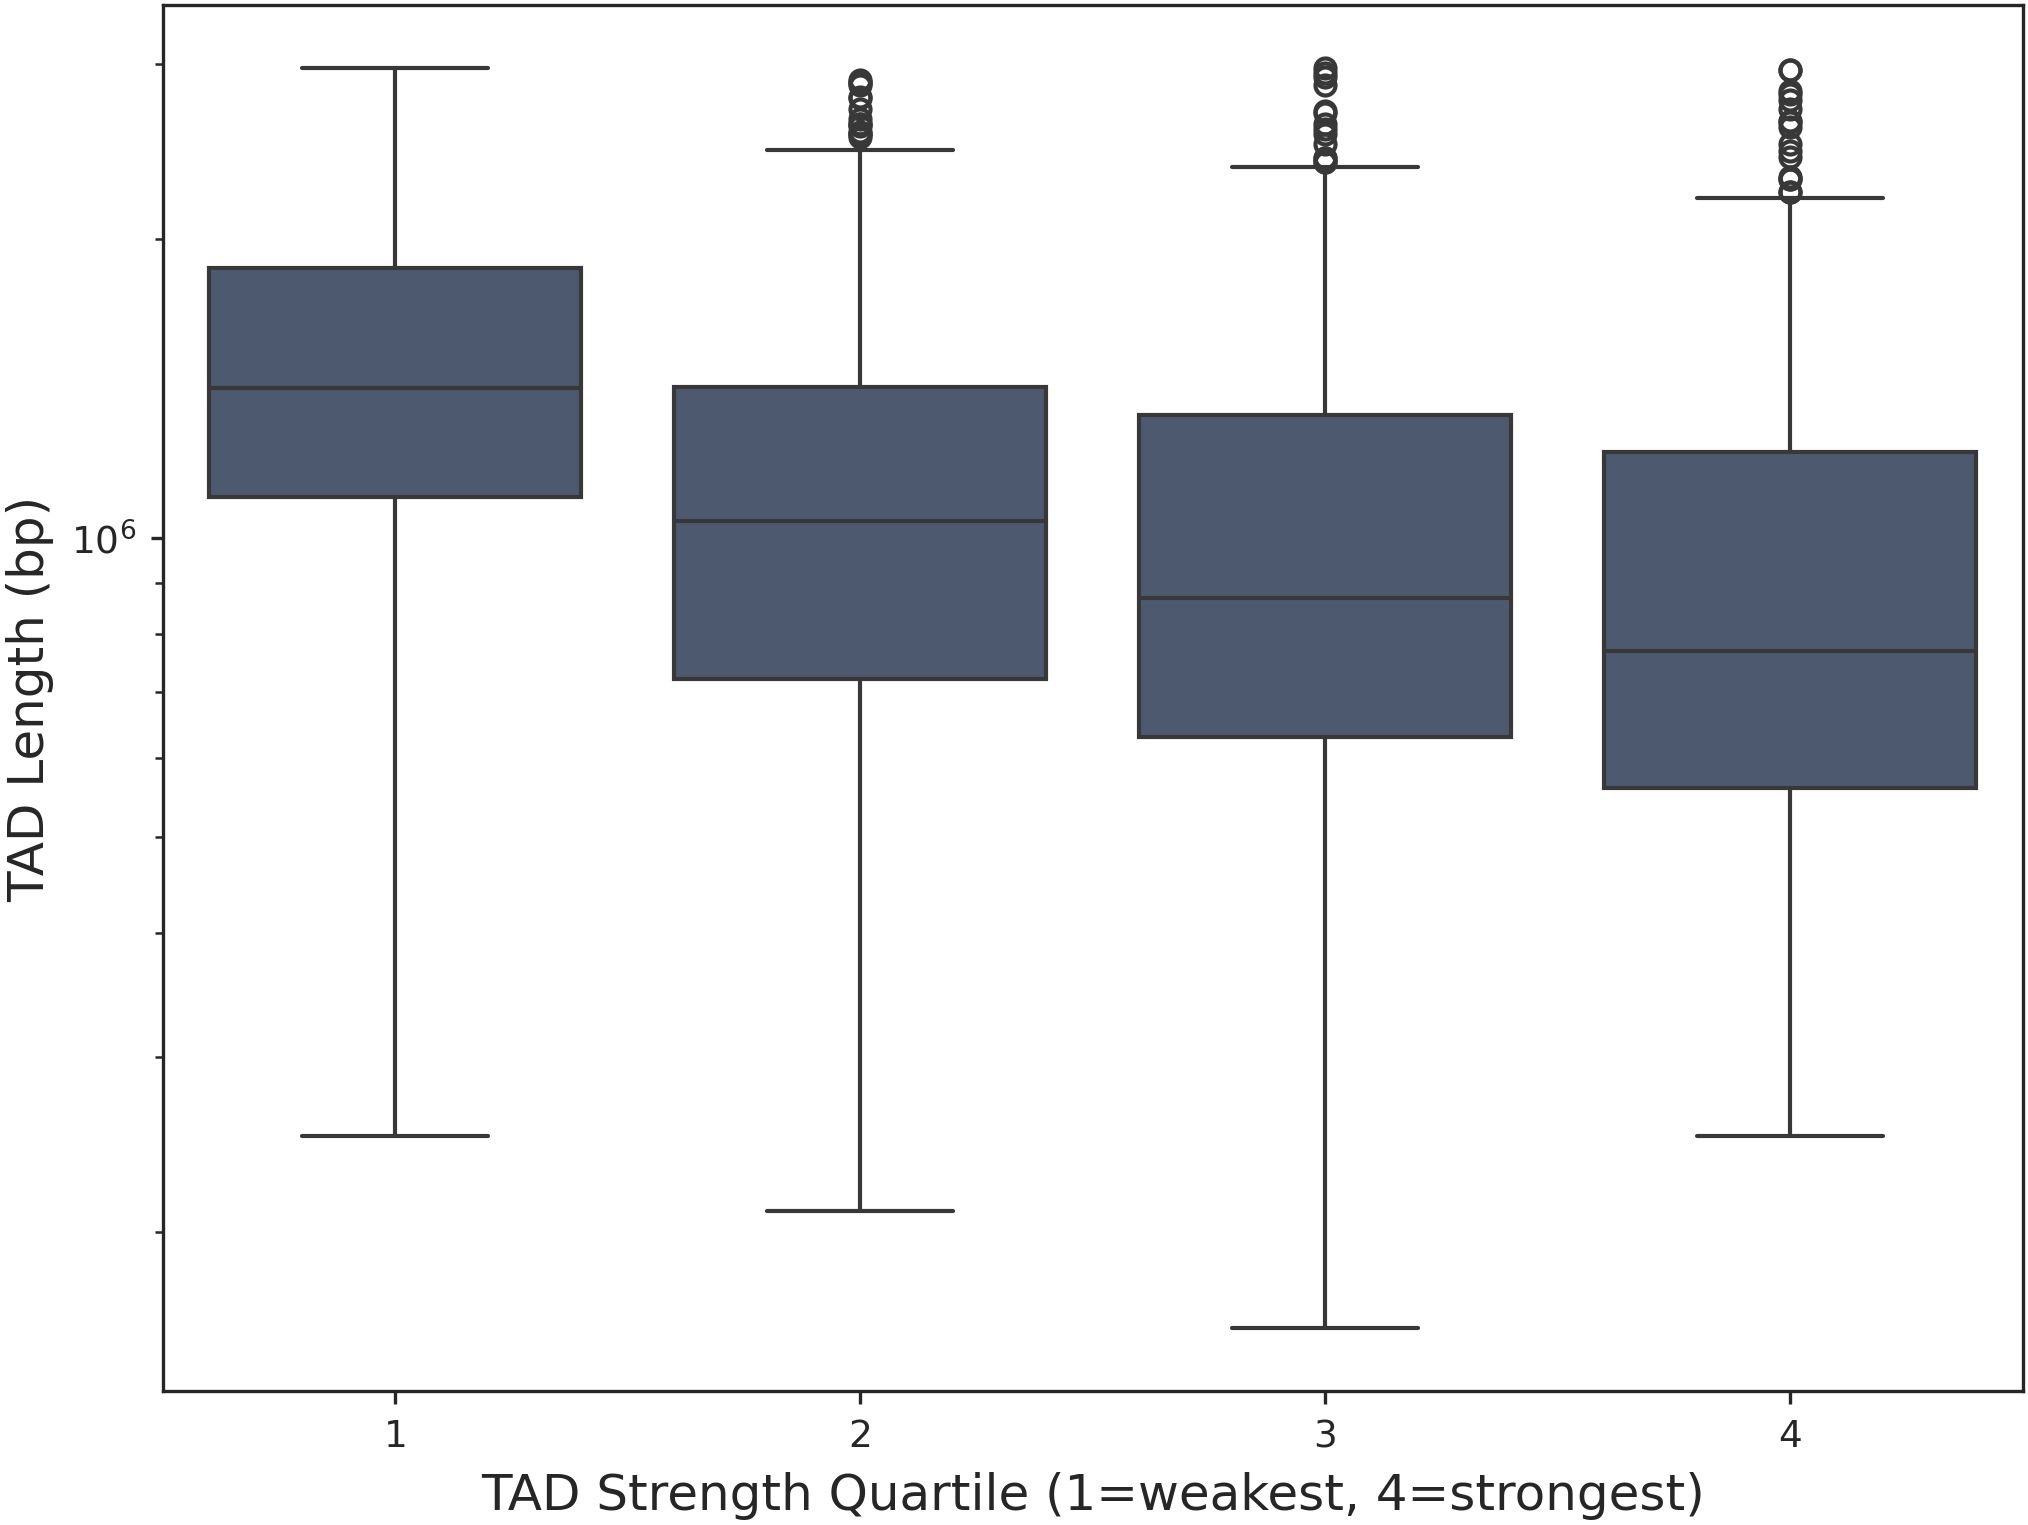

In [5]:
tad_str['Q'] = pd.qcut(tad_str['domain_score'], 4, labels=False) + 1
n_tad_per_q = tad_str['Q'].value_counts().sort_index().to_dict()


tad_str['length'] = tad_str['end'] - tad_str['start']

# viz lengths of tads per q

plt.figure(figsize=(8, 6))
sns.boxplot(x='Q', y='length', data=tad_str, order=[1, 2, 3, 4], color=plotting.COLORS[0])
plt.yscale('log')
plt.xlabel('TAD Strength Quartile (1=weakest, 4=strongest)')
plt.ylabel('TAD Length (bp)')
plt.show()

In [6]:
wt_pup = {}
view_df = prepare_view_df(arm=True)
for q in range(1, 5):
    for s in ['WTnoUV', 'WT3h']:
        expected = get_expected_cis_df(s, label='arm', resolution_kb=bin_bp // 1000)
        clr = clr_[s]
        if s not in wt_pup:
            wt_pup[s] = {}
        cc = coolpup.CoordCreator(tad_str.loc[tad_str['Q'] == q], resolution=10000, features_format='bed', local=True, rescale_flank=1)
        pup = coolpup.PileUpper(clr, cc, expected=expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=6).pileupsWithControl()
        wt_pup[s][q] = pup

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4_p', 'chr4_p'): 12
INFO:coolpuppy:('chr6_p', 'chr6_p'): 4
INFO:coolpuppy:('chr5_p', 'chr5_p'): 6
INFO:coolpuppy:('chr3_p', 'chr3_p'): 22
INFO:coolpuppy:('chr2_p', 'chr2_p'): 11
INFO:coolpuppy:('chr1_p', 'chr1_p'): 28
INFO:coolpuppy:('chr6_q', 'chr6_q'): 25
INFO:coolpuppy:('chr5_q', 'chr5_q'): 21
INFO:coolpuppy:('chr4_q', 'chr4_q'): 27
INFO:coolpuppy:('chr3_q', 'chr3_q'): 14
INFO:coolpuppy:('chr8_p', 'chr8_p'): 8
INFO:coolpuppy:('chr7_p', 'chr7_p'): 6
INFO:coolpuppy:('chr9_p', 'chr9_p'): 5
INFO:coolpuppy:('chr1_q', 'chr1_q'): 24
INFO:coolpuppy:('chr10_p', 'chr10_p'): 7
INFO:coolpuppy:('chr2_q', 'chr2_q'): 28
INFO:coolpuppy:('chr9_q', 'chr9_q'): 8
INFO:coolpuppy:('chr11_p', 'chr11_p'): 10
INFO:coolpuppy:('chr12_p', 'chr12_p'): 8
INFO:coolpuppy:('chr7_q', 'chr7_q'): 20
INFO:coolpuppy:('chr8_q', 'chr8_q'): 11
INFO:coolpuppy:('chr10_q', 'chr10_q'): 17
INFO:coolpuppy:('chr11_q', 'chr11_q'): 21
INFO:coolpuppy

In [7]:
wtnouv = []
wt3h = []
diffs = []
for q in range(1, 5):
    wtnouv.append(wt_pup['WTnoUV'][q].data[0])
    wt3h.append(wt_pup['WT3h'][q].data[0])
    diffs.append(wt_pup['WT3h'][q].data[0] - wt_pup['WTnoUV'][q].data[0])

mtx_data = [
    wtnouv,
    wt3h,
    diffs
]
vmin_raw, vmax_raw = np.nanmin([wtnouv, wt3h]), np.nanmax([wtnouv, wt3h])
vmin_diff, vmax_diff = -np.nanmax(np.abs(diffs)), np.nanmax(np.abs(diffs))

In [8]:
import matplotlib.colors as mcolors

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=4.0017)

Plotting row 0, Q1, vmin=0.0, vmax=4.0432491461328866
Plotting row 1, Q1, vmin=0.0, vmax=4.0432491461328866
Plotting row 2, Q1, vmin=-0.2316210603599247, vmax=0.2316210603599247
Plotting row 0, Q2, vmin=0.0, vmax=4.0432491461328866
Plotting row 1, Q2, vmin=0.0, vmax=4.0432491461328866
Plotting row 2, Q2, vmin=-0.2316210603599247, vmax=0.2316210603599247
Plotting row 0, Q3, vmin=0.0, vmax=4.0432491461328866
Plotting row 1, Q3, vmin=0.0, vmax=4.0432491461328866
Plotting row 2, Q3, vmin=-0.2316210603599247, vmax=0.2316210603599247
Plotting row 0, Q4, vmin=0.0, vmax=4.0432491461328866
Plotting row 1, Q4, vmin=0.0, vmax=4.0432491461328866
Plotting row 2, Q4, vmin=-0.2316210603599247, vmax=0.2316210603599247


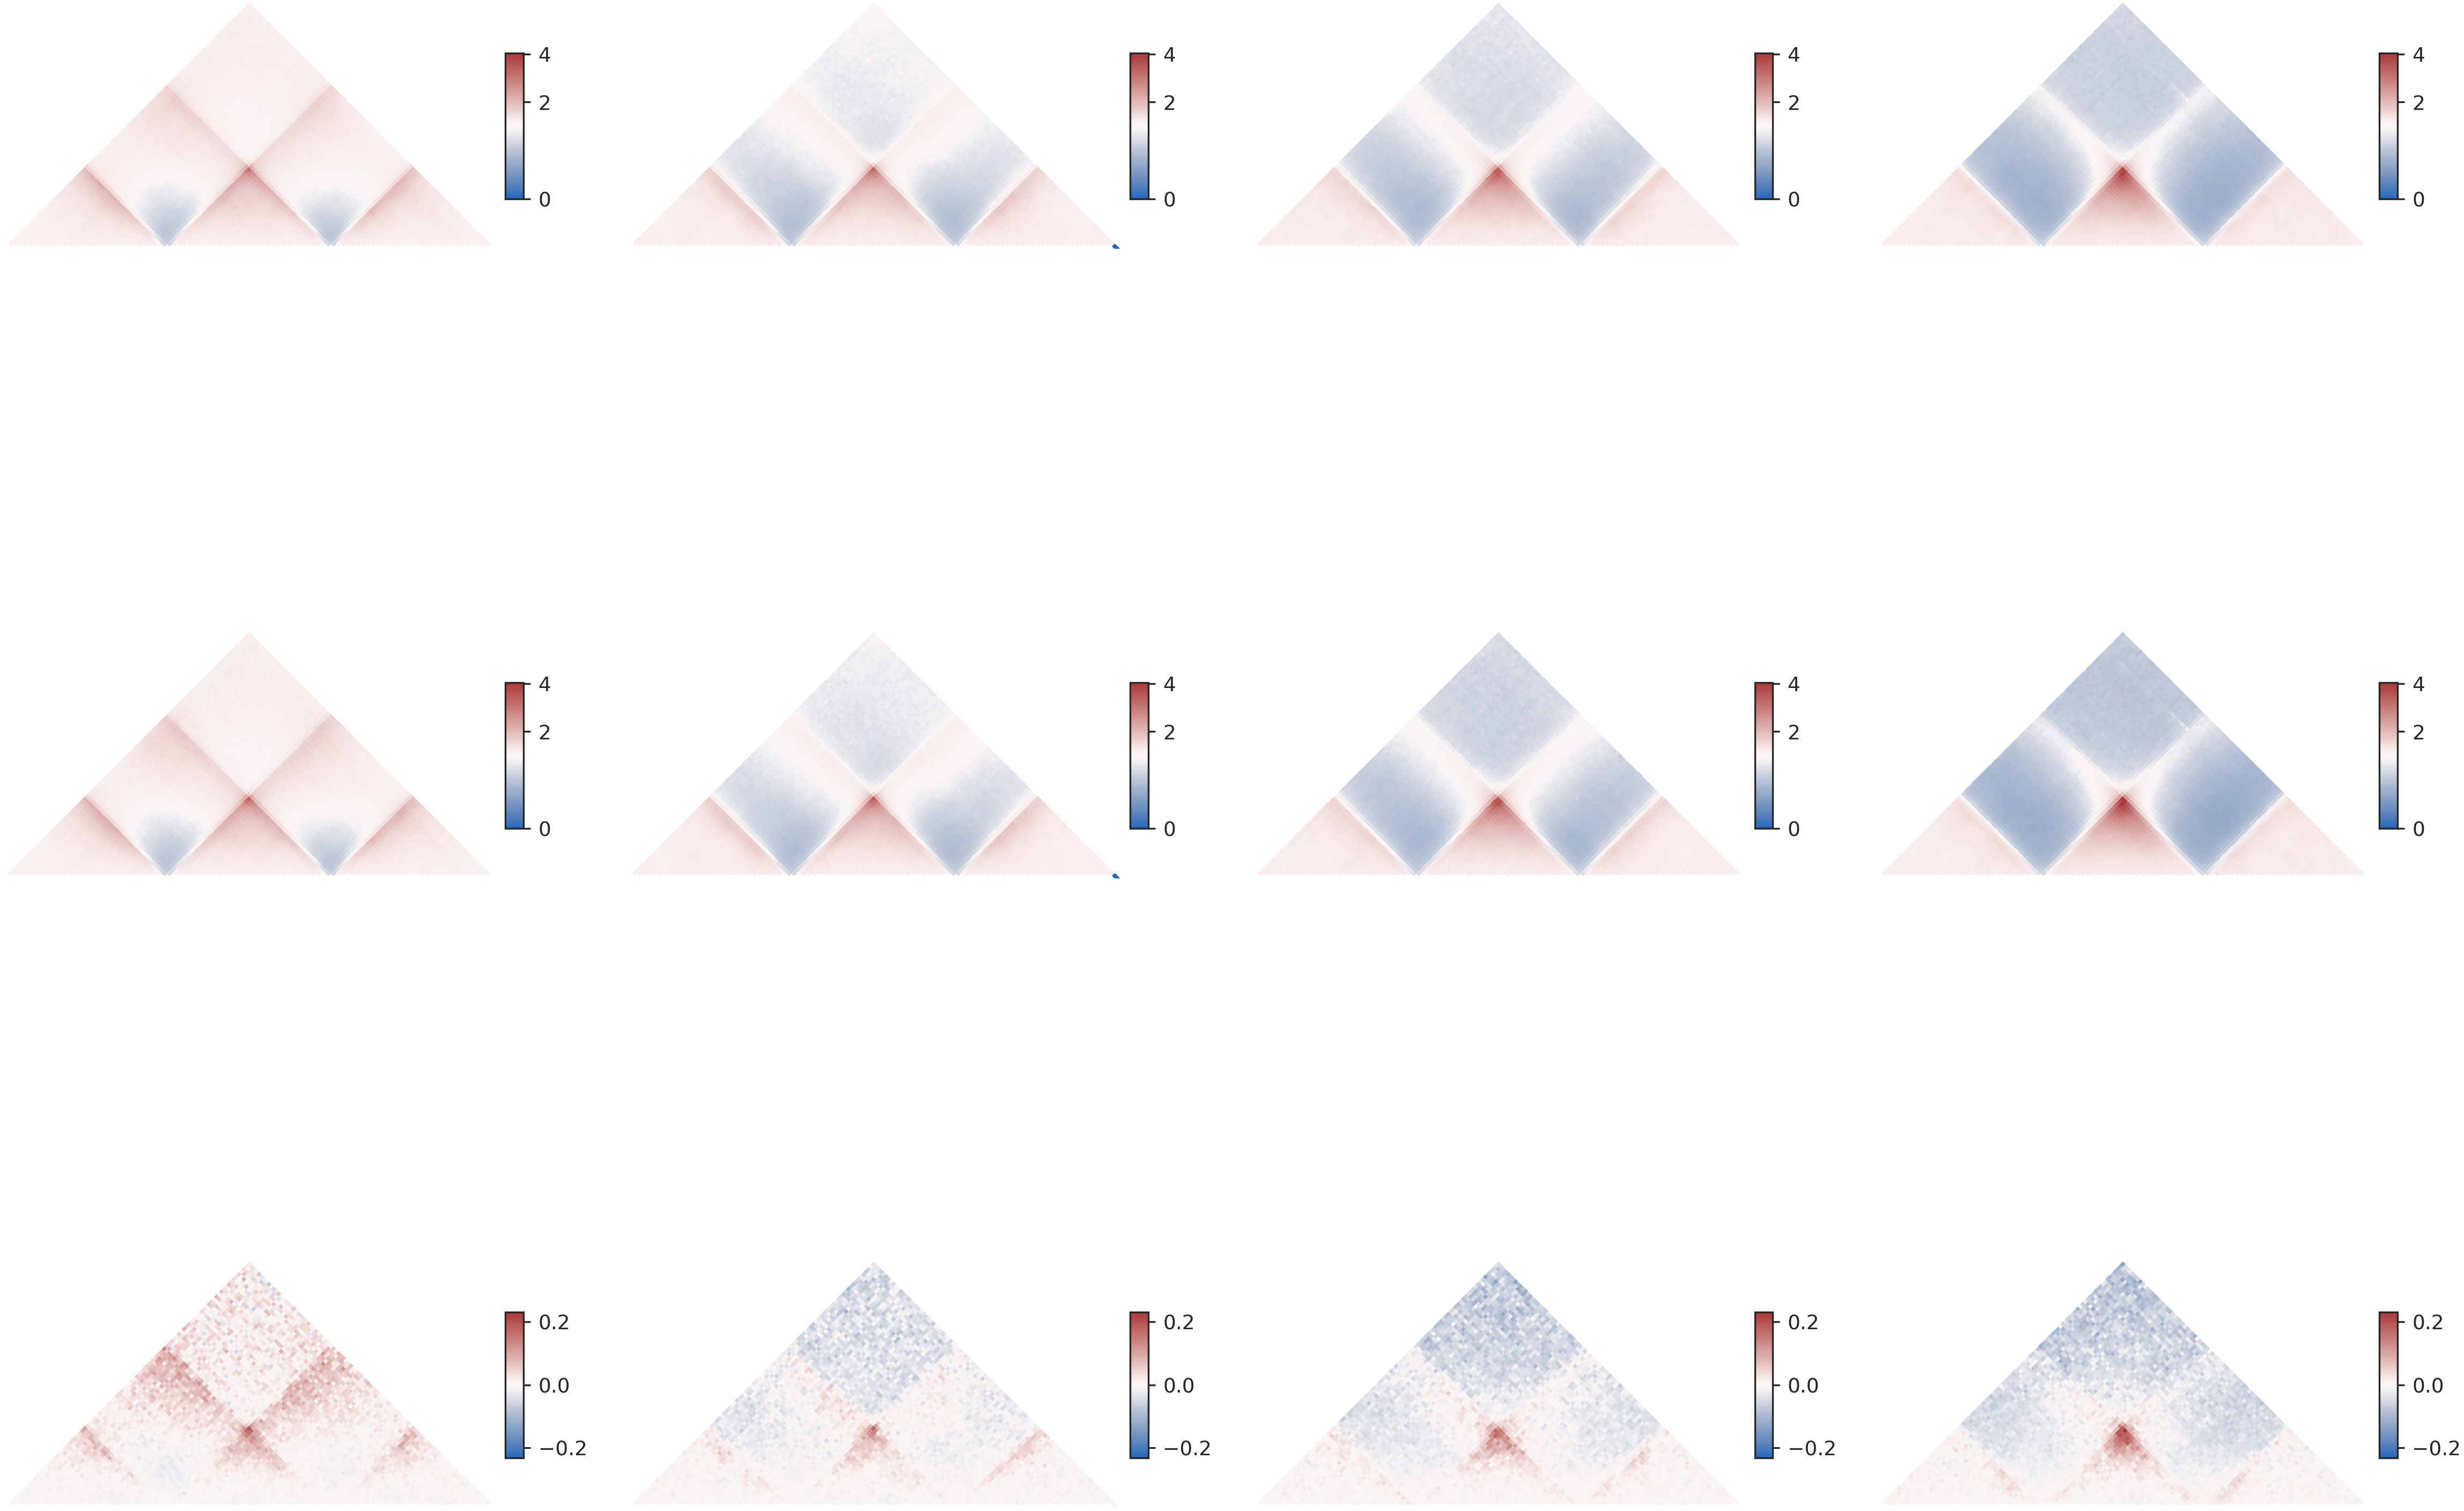

In [9]:
aspect_ratio = 4.8
fig, axs = plt.subplots(3, 4, figsize=(4*aspect_ratio, 3*aspect_ratio))
plotting.update_rcparams()

for q in range(4):
    for row in range(3):
        current_mtx = mtx_data[row][q]
        if row < 2:
            vmin, vmax = vmin_raw, vmax_raw
            current_center = 1
            title = f'WTnoUV' if row == 0 else 'WT3h'
        else:
            vmin, vmax = vmin_diff, vmax_diff
            current_center = 0
            title = 'WT3h - WTnoUV'
        
        print(f'Plotting row {row}, Q{q+1}, vmin={vmin}, vmax={vmax}')
        ax = plotting.hic_upper_triangle(
    current_mtx,
    cmap='vlag',
    center=current_center,   # <- scalar: 1 or 0 (or np.nanmedian(...))
    ax=axs[row, q],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8),
    vmin=vmin,
    vmax=vmax,
)